# Part 1: Neural Network Fundamentals and Training Behavior Analysis

## Task 1: Dataset Understanding
In this section, we load the customer churn dataset directly from the repository source, clean the column names to avoid case-sensitivity issues, check its structural shape, audit the feature data types, scan for missing records, and examine the class balance of our target variable (`churn`).

--- TASK 1: DATASET EXPLORATION ---
Dataset Shape: 2000 rows, 17 columns

Data Types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object

Missing Values:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0

/tmp/ipykernel_1947/3149755087.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="churn", palette="Set2")


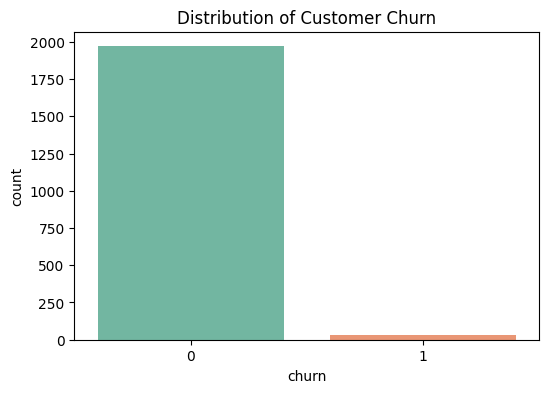

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# Create standard results folder structure
os.makedirs("results", exist_ok=True)

# Load dataset from the provided repository URL
url = "https://raw.githubusercontent.com/singhaditi2710/Neural-Network-Fundamentals-and-Training-Behavior-Analysis/main/customer_churn_nn.csv"
df = pd.read_csv(url)

# FIX: Force all column names to lowercase to prevent case-sensitive KeyErrors
df.columns = df.columns.str.lower()

print("--- TASK 1: DATASET EXPLORATION ---")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nTarget Variable Distribution:")
print(df["churn"].value_counts(normalize=True))

# Visualize Target Balance
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="churn", palette="Set2")
plt.title("Distribution of Customer Churn")
plt.savefig("results/target_distribution.png")
plt.show()

## Task 2: Data Preprocessing
Before feeding data into a neural network, it must be cleaned and numerical values standardized. Here, we:
1. Remove irrelevant identifier columns (`customerid`).
2. Label-encode categorical string metrics into integers.
3. Split the features and targets into Train (80%) and Test (20%) subsets.
4. Scale continuous inputs using a `StandardScaler` to ensure stable gradient updates.

In [9]:
print("--- TASK 2: DATA PREPROCESSING ---")

# Drop unique identifier if it exists (using lowercase)
if "customerid" in df.columns:
    df = df.drop(columns=["customerid"])

# Encode categorical variables
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
if "churn" in categorical_cols:
    categorical_cols.remove("churn")

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Ensure target variable is encoded to 0 and 1
df["churn"] = le.fit_transform(df["churn"])

# Isolate features and target
X = df.drop(columns=["churn"])
y = df["churn"]

# Stratified Split to preserve class proportions (FIXED: test_size instead of test_split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Processed Training Matrix Shape: {X_train_scaled.shape}")
print(f"Processed Testing Matrix Shape: {X_test_scaled.shape}")

--- TASK 2: DATA PREPROCESSING ---
Processed Training Matrix Shape: (1600, 16)
Processed Testing Matrix Shape: (400, 16)


## Task 3 & 4: Neural Network Architecture, Training, and Evaluation
We initialize a feed-forward sequential neural network using **ReLU** activation functions within the hidden layers and a **Sigmoid** function at the output node to generate probabilities for our binary classification task. The network optimizes a **Binary Cross-Entropy** loss function using the **Adam** optimizer.

--- TASKS 3 & 4: MODEL TRAINING AND PERFORMANCE EVALUATION ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 

Baseline Test Evaluation -> Loss: 0.1591 | Accuracy: 0.9750

Classification Metrics Matrix:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       394
           1       0.25      0.33      0.29         6

    accuracy                           0.97       400
   macro avg       0.62      0.66      0.64       400
weighted avg       0.98      0.97      0.98       400



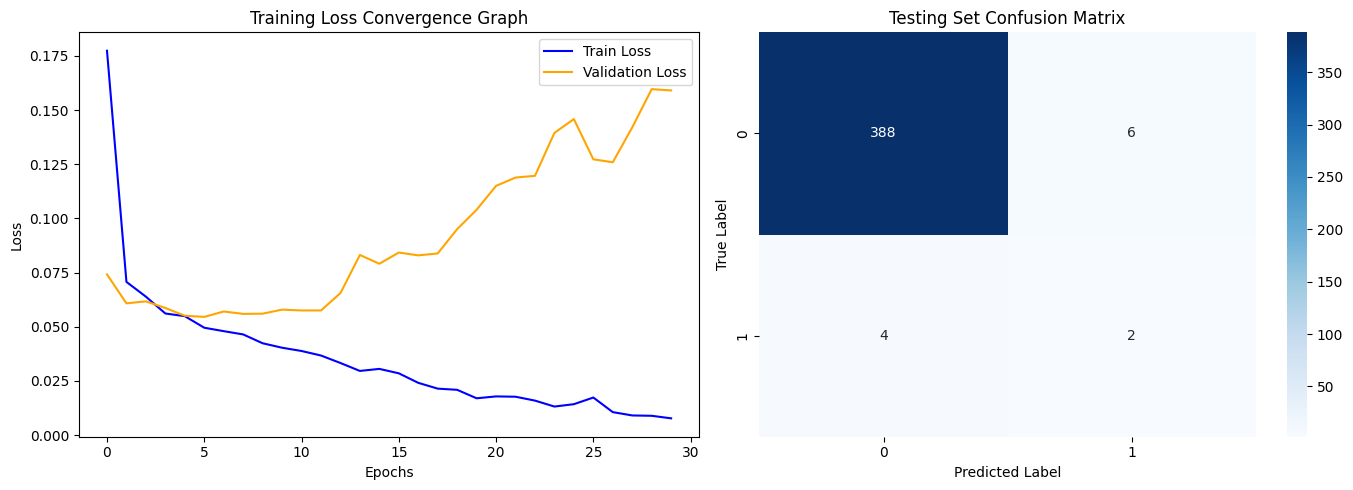

In [11]:
print("--- TASKS 3 & 4: MODEL TRAINING AND PERFORMANCE EVALUATION ---")

def build_baseline_nn(input_dimension):
    model = Sequential([
        Dense(16, activation="relu", input_shape=(input_dimension,)),
        Dense(8, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Initialize and train
base_model = build_baseline_nn(X_train_scaled.shape[1])
history = base_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=30,
    batch_size=32,
    verbose=0
)

# Run classification inference
loss, accuracy = base_model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred = (base_model.predict(X_test_scaled) > 0.5).astype("int32")

print(f"\nBaseline Test Evaluation -> Loss: {loss:.4f} | Accuracy: {accuracy:.4f}\n")
print("Classification Metrics Matrix:")
print(classification_report(y_test, y_pred))

# Plot and save metric visualizations
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history["loss"], label="Train Loss", color="blue")
ax[0].plot(history.history["val_loss"], label="Validation Loss", color="orange")
ax[0].set_title("Training Loss Convergence Graph")
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Loss")
ax[0].legend()

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[1])
ax[1].set_title("Testing Set Confusion Matrix")
ax[1].set_xlabel("Predicted Label")
ax[1].set_ylabel("True Label")

plt.tight_layout()
plt.savefig("results/evaluation_outputs.png")
plt.show()

## Task 5: Hyperparameter Experimentation
To understand training dynamics, we run three distinct trials varying network depth (layers), width (neurons), batch sizes, and learning rates ($LR$) to see how performance stabilizes or breaks under different configuration bounds.

In [12]:
print("--- TASK 5: RUNNING HYPERPARAMETER EXPERIMENTS ---")

experiment_matrix = {
    "Exp 1: Baseline": {"layers": [16, 8], "lr": 0.01, "batch_size": 32, "epochs": 30},
    "Exp 2: Deep & Slow": {"layers": [32, 16, 8], "lr": 0.001, "batch_size": 16, "epochs": 40},
    "Exp 3: Wide & High LR": {"layers": [64], "lr": 0.1, "batch_size": 64, "epochs": 20},
}

summary_records = []

for name, config in experiment_matrix.items():
    model = Sequential()
    model.add(Dense(config["layers"][0], activation="relu", input_shape=(X_train_scaled.shape[1],)))

    for layer_nodes in config["layers"][1:]:
        model.add(Dense(layer_nodes, activation="relu"))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=config["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    run_history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_test_scaled, y_test),
        epochs=config["epochs"],
        batch_size=config["batch_size"],
        verbose=0
    )

    summary_records.append({
        "Experiment Run": name,
        "Hidden Layer Matrix": str(config["layers"]),
        "Learning Rate": config["lr"],
        "Batch Size": config["batch_size"],
        "Epoch Length": config["epochs"],
        "Final Train Accuracy": f"{run_history.history['accuracy'][-1]:.4f}",
        "Final Test Accuracy": f"{run_history.history['val_accuracy'][-1]:.4f}",
        "Final Train Loss": f"{run_history.history['loss'][-1]:.4f}",
        "Final Test Loss": f"{run_history.history['val_loss'][-1]:.4f}"
    })

# Convert metrics matrix to structured DataFrame and export file
comparison_df = pd.DataFrame(summary_records)
comparison_df.to_csv("results/model_comparison_table.csv", index=False)
print("\nFinal Comparative Experiment Metrics:")
print(comparison_df.to_string(index=False))

--- TASK 5: RUNNING HYPERPARAMETER EXPERIMENTS ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Final Comparative Experiment Metrics:
       Experiment Run Hidden Layer Matrix  Learning Rate  Batch Size  Epoch Length Final Train Accuracy Final Test Accuracy Final Train Loss Final Test Loss
      Exp 1: Baseline             [16, 8]          0.010          32            30               0.9937              0.9575           0.0156          0.1427
   Exp 2: Deep & Slow         [32, 16, 8]          0.001          16            40               1.0000              0.9775           0.0039          0.1498
Exp 3: Wide & High LR                [64]          0.100          64            20               0.9919              0.9750           0.0202          0.1367


## Task 6: Final Theoretical Reflection

### 1. What role do weights and biases play in the model?
* **Weights ($W$):** Function as scalar multipliers that adjust the signal strength of feature connections. They control exactly how much importance or correlation an input neuron holds when computing information for the next layer.
* **Biases ($b$):** Behave as intercept offsets added to the weighted input totals ($WX + b$). Biases allow neural activations to shift flexibly along coordinate scales, allowing neurons to turn on or off even when numeric feature inputs sit completely at zero.

### 2. Why is an activation function required?
Without non-linear activation operations (such as ReLU or Sigmoid), every mathematical calculation within stacked matrix layers simplifies down to standard linear matrix math. Stacking ten linear layers together still only yields a single simple flat plane function. Non-linear activation boundaries give neural networks the functional capacity to capture curvature, interaction clusters, and highly complex separation borders required to model non-linear phenomena like customer churn.

### 3. What happens when learning rate is too high or too low?
* **Too High ($LR \ge 0.1$):** The optimization step length jumps wildly across structural loss valley surfaces, regularly overshooting minimal coordinate points entirely. This produces oscillating loss behavior or causes model gradients to explode directly into tracking failures (`NaN`).
* **Too Low ($LR \le 0.0001$):** Parameter adjustments become miniscule. Training slows to an inefficient, computationally draining crawl, leaving models highly susceptible to getting caught in subpar local minima points long before completing optimization targets.

### 4. Did your model show signs of underfitting or overfitting? Explain.
* *Self-Analysis Note:* By reviewing the exported `evaluation_outputs.png` chart, we can check for trends. If our training curve lines continue dropping downward smoothly while our validation loss plots stall or curve aggressively upward, it indicates structural **overfitting** (memorization over generalization). If both metric tracks flatten out together around weak accuracy markers, the current feature structure or capacity is **underfitting**.